In [ ]:
#Lab 3. Logistic Regression
#Given a suitable classification dataset:
#a) Identify the input features and target variable and split the dataset into training and testing sets.
#b) Build and train a Logistic Regression model.
#c) Explain the role of the sigmoid function in converting the model output into probability.
#d) Predict class labels and class probabilities for the test data and explain the role of the classification threshold.
#e) Evaluate the model using a confusion matrix and suitable classification measures.
#f) Plot the ROC curve and calculate AUC, where applicable.
#g) Change the classification threshold, observe its effect on predictions, and use the trained model to classify a new observation.


In [2]:
#a) Identify the input features and target variable and split the dataset into training and testing sets.

# Import pandas for handling the dataset
import pandas as pd

# Import train_test_split to divide the data into training and testing sets
from sklearn.model_selection import train_test_split

# Read the dataset
df = pd.read_csv("01_exam_pass_fail.csv")

# X contains all input features
# We remove "passed_exam" because it is our target variable
X = df.drop("passed_exam", axis=1)

# y contains the target variable
# 0 = Failed, 1 = Passed
y = df["passed_exam"]

# Convert categorical columns into numbers
# Logistic Regression needs numerical values
X = pd.get_dummies(X, drop_first=True)

# Split the dataset
# 80% data is used for training
# 20% data is used for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Display the size of training and testing data
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 7)
Testing data: (60, 7)


In [3]:
#b) Build and train a Logistic Regression model.

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
# max_iter=1000 gives the model enough iterations to learn
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")


Logistic Regression model trained successfully


In [4]:
#c) Explain the role of the sigmoid function in converting the model output into probability.

# Logistic Regression uses the sigmoid function internally.
# The sigmoid function converts the model output into a probability between 0 and 1.
#
# Probability close to 1 -> higher chance of Passed (class 1)
# Probability close to 0 -> higher chance of Failed (class 0)
#
# Example:
# 0.80 -> 80% probability of passing
# 0.20 -> 20% probability of passing

# Get probabilities for the test data
probabilities = model.predict_proba(X_test)

# Display the first 5 probability values
print("First 5 probability values:")
print(probabilities[:5])

First 5 probability values:
[[0.12091954 0.87908046]
 [0.81503677 0.18496323]
 [0.45551161 0.54448839]
 [0.41605155 0.58394845]
 [0.20628043 0.79371957]]


In [5]:
#d) Predict class labels and class probabilities for the test data and explain the role of the classification threshold.

# Predict the class labels for the test data
# 0 = Failed
# 1 = Passed
y_pred = model.predict(X_test)

# Predict probabilities for both classes
y_prob = model.predict_proba(X_test)

# Display predicted class labels
print("Predicted class labels:")
print(y_pred)

# Display probability of passing
# [:, 1] means we take the probability of class 1 (Passed)
print("\nProbability of Passing:")
print(y_prob[:, 1])

# The default classification threshold is 0.50
# Probability >= 0.50 -> Passed (1)
# Probability < 0.50  -> Failed (0)

threshold = 0.50

# Convert probabilities into class labels using the threshold
threshold_predictions = (y_prob[:, 1] >= threshold).astype(int)

print("\nPredictions using threshold 0.50:")
print(threshold_predictions)

Predicted class labels:
[1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 0]

Probability of Passing:
[0.87908046 0.18496323 0.54448839 0.58394845 0.79371957 0.34150872
 0.67649721 0.16953288 0.59144999 0.3786231  0.92491187 0.63055199
 0.73104703 0.53086696 0.66300723 0.87462217 0.74153839 0.93086728
 0.63045233 0.7168931  0.56993052 0.9457273  0.97234428 0.60986107
 0.79252723 0.61216045 0.36179447 0.89147935 0.55641602 0.92343347
 0.81163756 0.66992707 0.64967073 0.57087565 0.81506799 0.93146132
 0.88127022 0.58308954 0.56397137 0.88789248 0.71729231 0.85432729
 0.60596589 0.70344962 0.33755037 0.58488792 0.93663136 0.43320598
 0.55710894 0.55619886 0.39851912 0.5522037  0.88855062 0.418295
 0.9295757  0.8447732  0.51913767 0.7667149  0.68332373 0.45084985]

Predictions using threshold 0.50:
[1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 0]


In [6]:
#e) Evaluate the model using a confusion matrix and suitable classification measures.

# Import evaluation functions
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate Precision
precision = precision_score(y_test, y_pred)

# Calculate Recall
recall = recall_score(y_test, y_pred)

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Display all evaluation measures
print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Confusion Matrix:
[[ 4 17]
 [ 6 33]]

Accuracy: 0.6166666666666667
Precision: 0.66
Recall: 0.8461538461538461
F1-Score: 0.7415730337078652


AUC: 0.7716727716727717


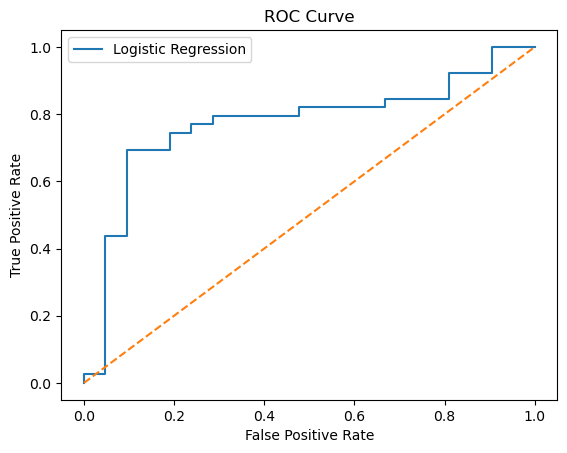

In [8]:
#f) Plot the ROC curve and calculate AUC, where applicable.

# Import ROC curve and AUC functions
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get False Positive Rate and True Positive Rate
# We use probability of class 1 (Passed)
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

# Calculate AUC
auc = roc_auc_score(y_test, y_prob[:, 1])

print("AUC:", auc)

# Plot the ROC curve
plt.plot(fpr, tpr, label="Logistic Regression")

# Plot the random classifier line
plt.plot([0, 1], [0, 1], linestyle="--")

# Add labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

# Display legend
plt.legend()

# Show the graph
plt.show()

In [9]:
#g) Change the classification threshold, observe its effect on predictions, and use the trained model to classify a new observation.

# Change the classification threshold from 0.50 to 0.70
threshold = 0.70

# Convert probabilities into class labels using the new threshold
# Probability >= 0.70 -> Passed (1)
# Probability < 0.70  -> Failed (0)
y_pred_new = (y_prob[:, 1] >= threshold).astype(int)

print("Predictions using threshold 0.70:")
print(y_pred_new)


# -------------------------------
# Classify a new student
# -------------------------------

# Create data for one new student
new_student = pd.DataFrame({
    "study_hours": [6],
    "attendance_pct": [85],
    "sleep_hours": [7],
    "previous_score": [75],
    "school_type": ["Public"],
    "study_mode": ["Full-time"],
    "region": ["Urban"]
})

# Convert categorical values into numbers
new_student = pd.get_dummies(new_student, drop_first=True)

# Make sure the new student has the same columns as the training data
new_student = new_student.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Predict the probability of passing
new_probability = model.predict_proba(new_student)[:, 1]

# Use 0.50 as the classification threshold
new_prediction = (new_probability >= 0.50).astype(int)

# Display the result
print("\nProbability of Passing:", new_probability[0])
print("Predicted Class:", new_prediction[0])

# Display the final result
if new_prediction[0] == 1:
    print("Result: Student is predicted to PASS")
else:
    print("Result: Student is predicted to FAIL")

Predictions using threshold 0.70:
[1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 0 1 1 1
 0 0 1 1 1 0 1 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0]

Probability of Passing: 0.8773970002993702
Predicted Class: 1
Result: Student is predicted to PASS
